# TP regressions lineaire

In [54]:
# J'importe toutes mes librairies
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from scipy import stats
import numpy as np

In [8]:
df = pd.read_csv('2/maison_prix_tabulaire.csv')
df.head()

,surface_m2,rooms,age_years,price_keuro
0,143.83,4,34.1,367.03
1,90.22,2,27.8,256.99
2,157.38,4,31.4,410.29
3,131.58,4,16.5,325.75
4,35.07,1,22.8,125.78


## 1. Exploration des données

In [ ]:
df.describe()
# Cette fonction nous permet de voir les statisques qui nous serviront plus tard comment les outliers,etc...

,surface_m2,rooms,age_years,price_keuro
count,200.000000,200.000000,200.000000,200.000000
mean,99.019400,2.890000,24.412500,271.801400
std,45.169808,1.448583,11.874926,113.044342
min,21.180000,1.000000,0.000000,68.910000
25%,60.352500,2.000000,15.750000,173.932500
50%,96.640000,3.000000,24.200000,269.805000
75%,139.562500,4.000000,31.775000,373.282500
max,178.780000,6.000000,56.200000,506.070000


In [ ]:
df.isnull().sum()
# je regarde si j'ai des donnes vides pour ne pas bruité les resultats

surface_m2     0
rooms          0
age_years      0
price_keuro    0
dtype: int64

In [ ]:
df.info()
# Je vois ici que nous avons des données numeriques

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   surface_m2   200 non-null    float64
 1   rooms        200 non-null    int64  
 2   age_years    200 non-null    float64
 3   price_keuro  200 non-null    float64
dtypes: float64(3), int64(1)
memory usage: 6.4 KB


In [ ]:
df_zscores = pd.DataFrame(zscores, columns=df.columns)
df_zscores.head(10) #J'affiche le z-score pour voir les outliers (l'écart des valeurs par rapport a la mean de l'ecart type)

#Aucunes données dans superieur a 3 donc 0 outliers

,surface_m2,rooms,age_years,price_keuro
0,0.994537,0.768189,0.817842,0.844514
1,-0.195296,-0.615935,0.285981,-0.131352
2,1.295269,0.768189,0.589901,1.228156
3,0.722658,0.768189,-0.667992,0.478432
4,-1.419308,-1.307998,-0.136131,-1.294959
5,1.710745,2.152314,0.252212,1.673167
6,0.949039,0.768189,0.876937,1.090255
7,1.037594,1.460251,-0.347187,1.019042
8,-1.298793,-1.307998,0.581459,-1.407498
9,-0.154459,0.076127,-0.220553,-0.012871


surface_m2      79.210
rooms            2.000
age_years       16.025
price_keuro    199.350
dtype: float64


<Axes: >

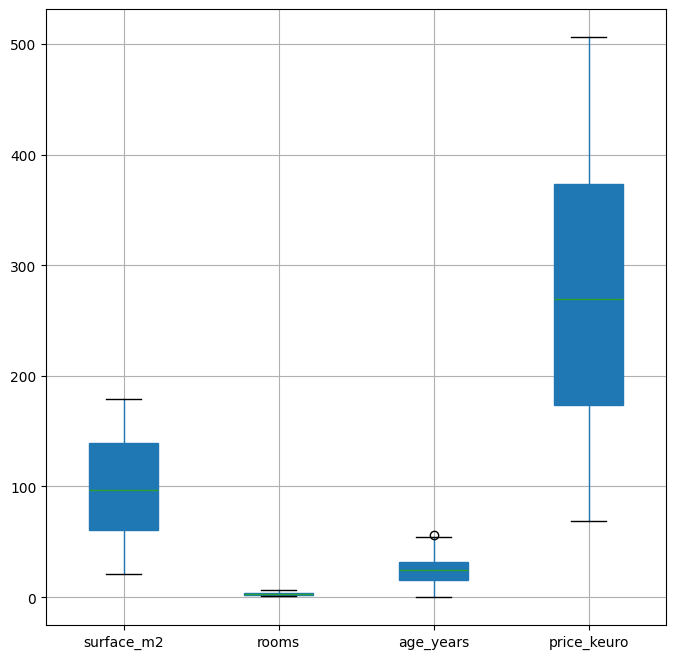

In [40]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)   #j'affiche ensuite les outliers avec l'iqr 
IQR = Q3 - Q1
print(IQR)

zscores = stats.zscore(df)
zscores

df.boxplot(patch_artist=True, figsize=(8,8))  #Puis en boxplot pour la visualisation

# Il n'y a pas d'outliers

## 2. Visualisation

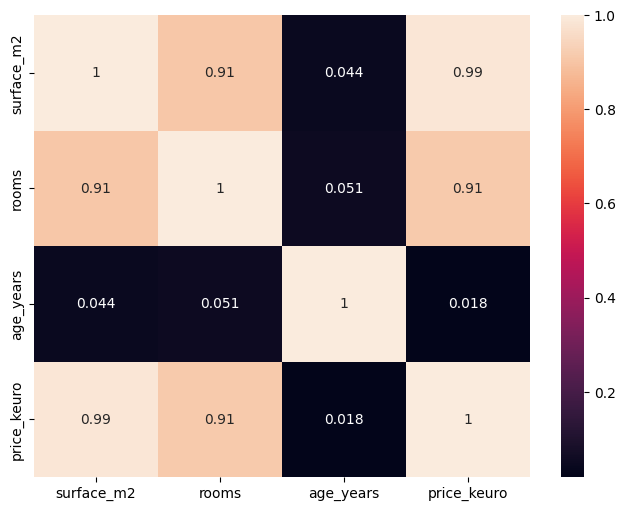

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True) # J'affiche la matrice de corrélation 
plt.show()

## 3. Séparation train/test

In [ ]:
print(df.shape) #Je regarde la taille des données pour la répartition de X et y

(200, 4)


In [50]:
from sklearn.model_selection import train_test_split

X = df[['surface_m2', 'rooms', 'age_years']]  #Je sépare les donnée
y = df['price_keuro']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## 5. Entraînement du modèle
Instancier et fit un `LinearRegression` de scikit-learn.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test) #Je charge mon modéle et je prepare les evaluations du modéle


print("R²:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))


R²: 0.9709350149833622
RMSE: 19.02932903621335


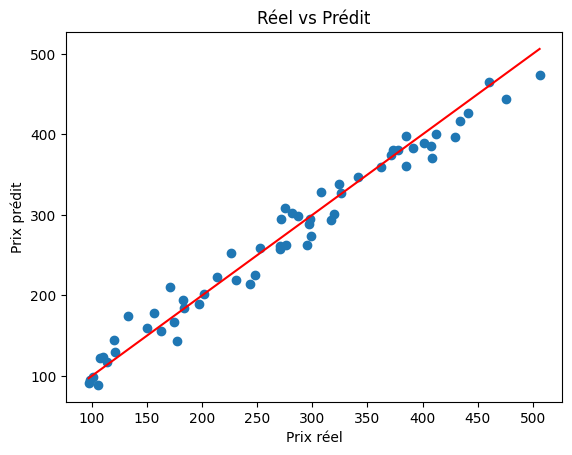

In [ ]:
plt.scatter(y_test, y_pred)
plt.xlabel('Prix réel')
plt.ylabel('Prix prédit')   #J'affiche la courbe de la regression lineaire pour y voir le variance (R²)
plt.title('Réel vs Prédit')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red')
plt.show()

In [ ]:
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_) #J'affiche les coef et les intercept pour comprendre l'impact des variables

Coefficients: [ 2.20966632  7.88577818 -0.20037158]
Intercept: 34.347911526881376


In [ ]:
from ipywidgets import interact, IntSlider

def predict_price(surface, rooms, age):
    prix = model.predict([[surface, rooms, age]])[0]  #Gadget
    print(f"Prix prédit : {prix:.2f} k€")

interact(predict_price,
         surface=IntSlider(min=20, max=300, step=5, value=80, description='Surface m²'),
         rooms=IntSlider(min=1, max=10, step=1, value=3, description='Pièces'),
         age=IntSlider(min=0, max=50, step=1, value=10, description='Âge (ans)'))

interactive(children=(IntSlider(value=80, description='Surface m²', max=300, min=20, step=5), IntSlider(value=…

<function __main__.predict_price(surface, rooms, age)>